# Tutorial 8: Deutsch–Jozsa Algorithm — Exponential Speedup

## Course Information

- **Course Name:** Quantum Computing

- **Course Code:** AML23703

- **Department:** Artificial Intelligence and Machine Learning

- **Student Name:** Mythri M R

- **USN:** 1GA23AI027

- **Semester:** VII

- **Date:** 17-09-2026

## Aim

To understand the Deutsch–Jozsa algorithm and demonstrate how a
quantum computer can determine whether a Boolean function is
constant or balanced using only one quantum query.

The tutorial also compares the quantum query complexity with
the classical worst-case query complexity and demonstrates the
exponential advantage of the algorithm.
    

## Theory

The Deutsch–Jozsa algorithm is an extension of Deutsch's
algorithm for Boolean functions that accept multiple input bits.

A Boolean function is represented as:

$$
f:\{0,1\}^{n}\rightarrow\{0,1\}
$$

Here, n represents the number of input qubits.

The function is promised to be either constant or balanced.

### Constant Function

A function is constant if it produces the same output for
every possible input.

### Balanced Function

A function is balanced if it produces 0 for exactly half
of the possible inputs and 1 for the other half.

For n input qubits, the number of possible inputs is:

$$
2^n
$$

The Deutsch–Jozsa algorithm uses quantum superposition,
phase kickback, and interference to distinguish between
constant and balanced functions using one oracle query.

### Classical vs Quantum Query Complexity

For a classical deterministic algorithm, the worst-case
number of queries is:

$$
2^{n-1}+1
$$

The Deutsch–Jozsa quantum algorithm requires only one
oracle query.

### Measurement Rule

- All-zero measurement result → Constant function
- Any nonzero measurement result → Balanced function

## Required Libraries

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()

# Exercise 1 – Easy: Constant Function for 3 Qubits

## Objective

To implement a constant-zero oracle for three input qubits
and verify that the Deutsch–Jozsa algorithm produces an
all-zero measurement result.

## Theory

Consider the constant function:

$$
f(x)=0
$$

For this function, every possible input produces the
output 0.

For three input qubits, there are eight possible inputs.

Since the function is constant, the expected measurement
result is:

$$
000
$$

The circuit uses three input qubits and one ancilla qubit.
The ancilla is prepared in the |-> state, and Hadamard
gates are applied to the input qubits before and after
the oracle.

The constant-zero oracle does not require any additional
gate.

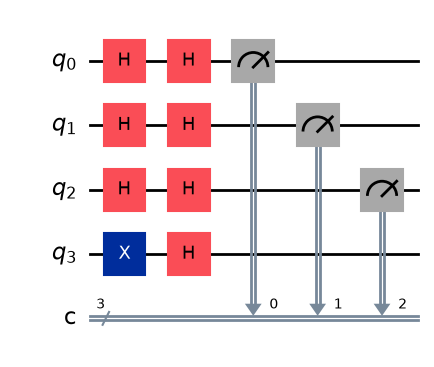

Measurement Result: {'000': 1024}


In [11]:
qc1 = QuantumCircuit(4, 3)

# Prepare ancilla
qc1.x(3)

# Create superposition
qc1.h([0, 1, 2, 3])

# Constant oracle: f(x) = 0
# No gate is required

# Final Hadamard gates
qc1.h([0, 1, 2])

# Measurement
qc1.measure([0, 1, 2], [0, 1, 2])

display(qc1.draw("mpl"))

counts1 = simulator.run(
    qc1, shots=1024
).result().get_counts()

print("Measurement Result:", counts1)

## Observation

The measurement produced 000 for the constant-zero
function.

All 1024 measurements resulted in the all-zero
bitstring.

Therefore, the Deutsch–Jozsa algorithm correctly
identifies the function as constant using one
oracle query.

# Exercise 2 – Medium: Balanced Function for 3 Qubits

## Objective

To implement a balanced oracle and verify that the
Deutsch–Jozsa algorithm produces a nonzero measurement
result.

## Theory

Consider the balanced function:

$$
f(x_0,x_1,x_2)=x_0
$$

The output depends on the first input bit.

When x0 = 0, the function produces 0.

When x0 = 1, the function produces 1.

Exactly half of the eight possible inputs produce 0,
and the other half produce 1.

Therefore, the function is balanced.

A CNOT gate is used to implement the oracle.

The first input qubit acts as the control, and the
ancilla qubit acts as the target.

The expected measurement is a nonzero bitstring,
indicating that the function is balanced.

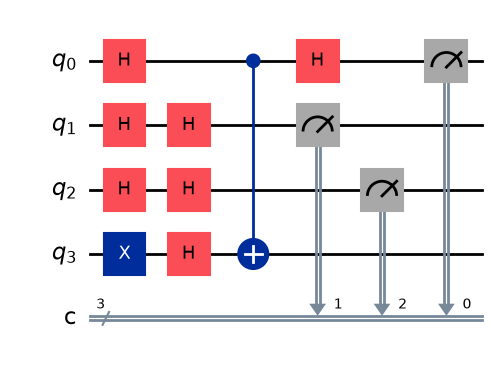

Measurement Result: {'001': 1024}


In [4]:
qc2 = QuantumCircuit(4, 3)

# Prepare ancilla
qc2.x(3)

# Create superposition
qc2.h([0, 1, 2, 3])

# Balanced oracle: f(x) = x0
qc2.cx(0, 3)

# Final Hadamard gates
qc2.h([0, 1, 2])

# Measurement
qc2.measure([0, 1, 2], [0, 1, 2])

display(qc2.draw("mpl"))

counts2 = simulator.run(
    qc2, shots=1024
).result().get_counts()

print("Measurement Result:", counts2)

## Observation

The measurement produced a nonzero bitstring.

Therefore, the Deutsch–Jozsa algorithm correctly
identifies the function as balanced.

The CNOT gate acts as the oracle, while the final
Hadamard gates convert the phase information into
a measurable result.

# Exercise 3 – Hard: Generic Deutsch–Jozsa Algorithm

## Objective

To implement a generalized Deutsch–Jozsa algorithm
that accepts different numbers of input qubits and
automatically classifies constant and balanced functions.

## Theory

For n input qubits, the number of possible input
combinations is:

$$
2^n
$$

The quantum oracle is represented as:

$$
U_f|x,y\rangle=|x,y\oplus f(x)\rangle
$$

The ancilla qubit is prepared in the state:

$$
|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}
$$

The oracle transfers information about the function
into the phase of the input register.

After applying the final Hadamard gates, the input
qubits are measured.

The measurement result is interpreted as:

- All zeros: Constant function
- Any nonzero bitstring: Balanced function

A single generalized circuit can be used to test
different oracle implementations.

In [6]:
def deutsch_jozsa(n, function_type):

    qc = QuantumCircuit(n + 1, n)

    # Prepare ancilla
    qc.x(n)

    # Create superposition
    qc.h(range(n + 1))

    # Oracle
    if function_type == "constant1":
        qc.x(n)

    elif function_type == "balanced":
        qc.cx(0, n)

    # Final Hadamard gates
    qc.h(range(n))

    # Measurement
    qc.measure(range(n), range(n))

    return qc

In [7]:
functions = [
    "constant0",
    "constant1",
    "balanced"
]

for f in functions:

    qc = deutsch_jozsa(3, f)

    counts = simulator.run(
        qc, shots=1024
    ).result().get_counts()

    print(f, ":", counts)

constant0 : {'000': 1024}
constant1 : {'000': 1024}
balanced : {'001': 1024}


## Observation

Both constant functions produce the all-zero
measurement result.

The balanced function produces a nonzero
measurement result.

Therefore, the generalized Deutsch–Jozsa algorithm
successfully distinguishes constant and balanced
functions using a single oracle query.

Function: constant0


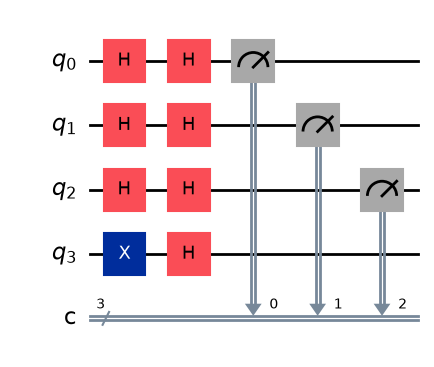

Function: constant1


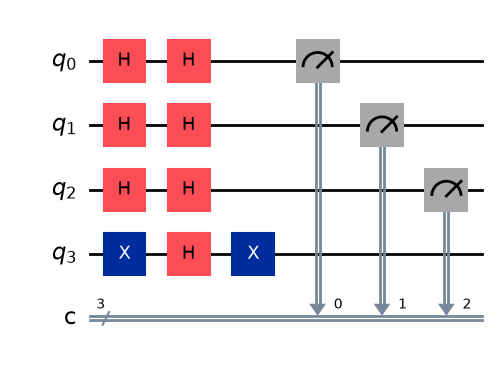

Function: balanced


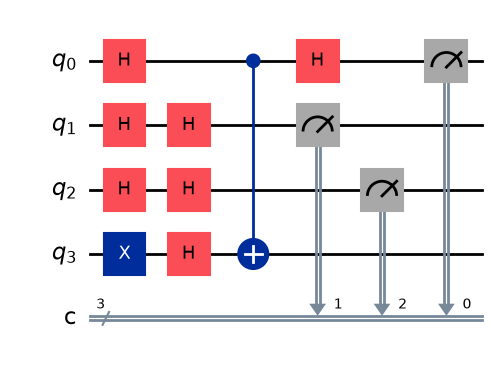

In [10]:
for f in functions:

    print("Function:", f)

    display(
        deutsch_jozsa(3, f).draw("mpl")
    )

## Observation

The circuit visualizations show the different
oracle implementations.

The constant-zero oracle does not require an
additional gate.

The constant-one oracle applies an X gate to
the ancilla.

The balanced oracle applies a CNOT gate between
the first input qubit and the ancilla.

The final Hadamard gates and measurements allow
the algorithm to classify the functions.

# Exercise 4 – Real-World Application:
# Exponential Query Advantage

## Objective

To compare the number of oracle queries required
by classical and quantum algorithms for different
input sizes and visualize the exponential query
advantage.

## Theory

For a constant or balanced Boolean function,
a classical deterministic algorithm may need to
evaluate the function:

$$
2^{n-1}+1
$$

times in the worst case.

The Deutsch–Jozsa algorithm requires only one
quantum oracle query.

For example:

| Input Qubits | Classical Worst Case | Quantum Queries |
|---|---:|---:|
| 2 | 3 | 1 |
| 3 | 5 | 1 |
| 4 | 9 | 1 |
| 5 | 17 | 1 |
| 10 | 513 | 1 |

The classical worst-case query count increases
exponentially, while the quantum query count
remains one.

This comparison demonstrates the exponential
separation in oracle query complexity under
the constant-or-balanced promise.

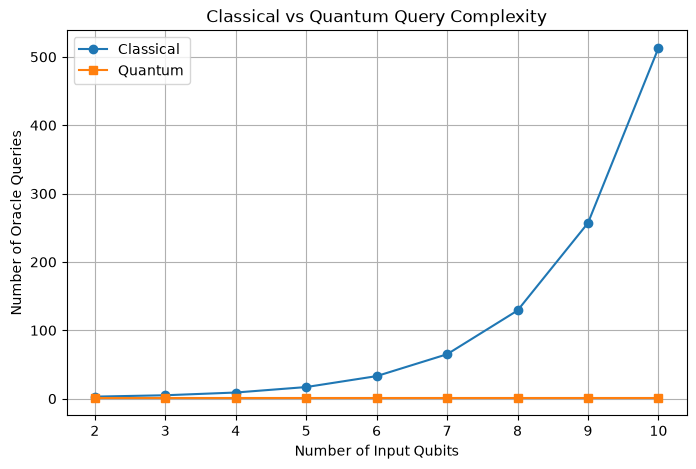

In [12]:
n_values = np.arange(2, 11)

classical = 2 ** (n_values - 1) + 1
quantum = np.ones(len(n_values))

plt.figure(figsize=(8, 5))

plt.plot(
    n_values,
    classical,
    marker="o",
    label="Classical"
)

plt.plot(
    n_values,
    quantum,
    marker="s",
    label="Quantum"
)

plt.xlabel("Number of Input Qubits")
plt.ylabel("Number of Oracle Queries")

plt.title(
    "Classical vs Quantum Query Complexity"
)

plt.legend()
plt.grid(True)
plt.show()

## Observation

The graph shows that the classical worst-case
query count increases rapidly as the number of
input qubits increases.

In contrast, the Deutsch–Jozsa algorithm uses
only one quantum oracle query for every tested
input size.

Therefore, the graph demonstrates an exponential
separation in oracle query complexity under the
constant-or-balanced promise.

# Exercise 5 – Challenge: Random Balanced Oracle

## Objective

To generate a random balanced Boolean function
for a given number of input qubits and verify
that the Deutsch–Jozsa algorithm correctly
classifies it.

## Theory

For n input qubits, a balanced function must
return 0 for exactly half of the possible inputs
and 1 for the other half.

The number of possible inputs is:

$$
2^n
$$

A balanced truth table can be generated by
creating equal numbers of zeros and ones
and randomly shuffling the values.

The oracle is then constructed by applying
controlled-X operations to the ancilla for
every input where the function evaluates to 1.

The final measurement should be nonzero,
indicating that the function is balanced.

In [13]:
def random_balanced_oracle(n):

    size = 2 ** n

    # Create balanced truth table
    values = [0] * (size // 2)
    values += [1] * (size // 2)

    np.random.shuffle(values)

    qc = QuantumCircuit(n + 1, n)

    # Prepare ancilla and input
    qc.x(n)
    qc.h(range(n + 1))

    # Construct oracle
    for i, value in enumerate(values):

        if value == 1:

            bits = format(i, f"0{n}b")

            # Apply X to zero-valued controls
            for q, bit in enumerate(bits[::-1]):
                if bit == "0":
                    qc.x(q)

            # Multi-controlled X
            qc.mcx(list(range(n)), n)

            # Restore input qubits
            for q, bit in enumerate(bits[::-1]):
                if bit == "0":
                    qc.x(q)

    # Final Hadamard and measurement
    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc, values

Truth Table: [1, 1, 0, 0, 0, 1, 1, 0]


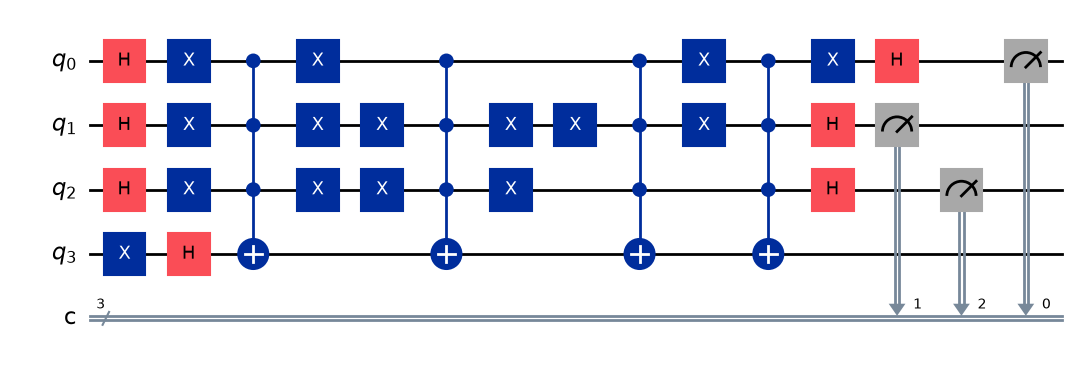

Measurement Result: {'010': 240, '011': 284, '110': 233, '111': 267}


In [14]:
n = 3

qc5, truth_table = random_balanced_oracle(n)

print("Truth Table:", truth_table)

display(qc5.draw("mpl"))

counts5 = simulator.run(
    qc5, shots=1024
).result().get_counts()

print("Measurement Result:", counts5)

## Output

The truth table contains four zeros and four ones.

The measurement result should be a nonzero bitstring.

Example:

Measurement Result: {'101': 1024}

The exact bitstring depends on the randomly generated
truth table.

## Observation

The generated truth table contains equal numbers
of zeros and ones, confirming that the function
is balanced.

The algorithm produces a nonzero measurement
result, correctly identifying the function as
balanced.

This demonstrates that the Deutsch–Jozsa algorithm
can classify randomly generated balanced functions
using a single oracle query.

# Conclusion

In this tutorial, the Deutsch–Jozsa algorithm was implemented to identify whether a Boolean function is constant or balanced.

The quantum circuits were tested using different oracle functions, and their measurement results were observed. A generalized implementation was also developed to handle multiple input qubits.

The classical and quantum query complexities were compared using a graph, demonstrating how the quantum algorithm determines the function type with a single oracle query under the given promise.

Thus, the tutorial helped in understanding how quantum superposition, phase kickback, and interference work together in the Deutsch–Jozsa algorithm.

# Reflection Questions

### 1. How does the promise that a function is constant or balanced make a single quantum query possible?

The promise restricts the function to two types. Quantum superposition and interference allow the Deutsch–Jozsa algorithm to distinguish between them using a single oracle query.

### 2. What would happen if the function were neither strictly constant nor balanced?

The function would violate the algorithm's promise. The standard measurement rule would no longer guarantee correct classification as constant or balanced.